In [107]:
from deltasigma import *
import numpy as np
from matplotlib.pyplot import *
import warnings
from scipy.signal import ss2zpk
warnings.filterwarnings('ignore')

In [108]:
order = 2
osr = 256 # oversampling ratio
nlev = 2 # adc quantization level - 2 bits since single comparator is used
f0 = 0.0 # center frequency 0
Hinf = 2 # maximum out-of-band NTF gain
tdac = [0, 1] # pulse timing (NRZ)
form = 'FB' # cascade of integrators, feedback. naming it to FB because realizeNTF_ct only takes FB and FF
M = nlev - 1 # quantizer step normalized to +/- 1
plotsize = (6,6)

In [109]:
print(f"{order}-order CT-DSM")
print("Doing NTF Synthesis...")
ntf0 = synthesizeNTF(order, osr, 2, Hinf, f0) # returns [(z1, p1), ...] for NTF 
print("Done.")
print(f"Synthesized a {order}-order NTF, with roots: ")
print("Zeroes: \t\t\t Poles:")
for z, p in zip(ntf0[0], ntf0[1]):
    print(f"({np.real(z):.8f},{np.imag(z):.8f}j), ({np.real(p):.8f}, {np.imag(p):.8f}j)")

2-order CT-DSM
Doing NTF Synthesis...
Done.
Synthesized a 2-order NTF, with roots: 
Zeroes: 			 Poles:
(1.00000000,0.00000000j), (0.38196601, -0.30028311j)
(1.00000000,0.00000000j), (0.38196601, 0.30028311j)


Generating NTF pole-zero plot...


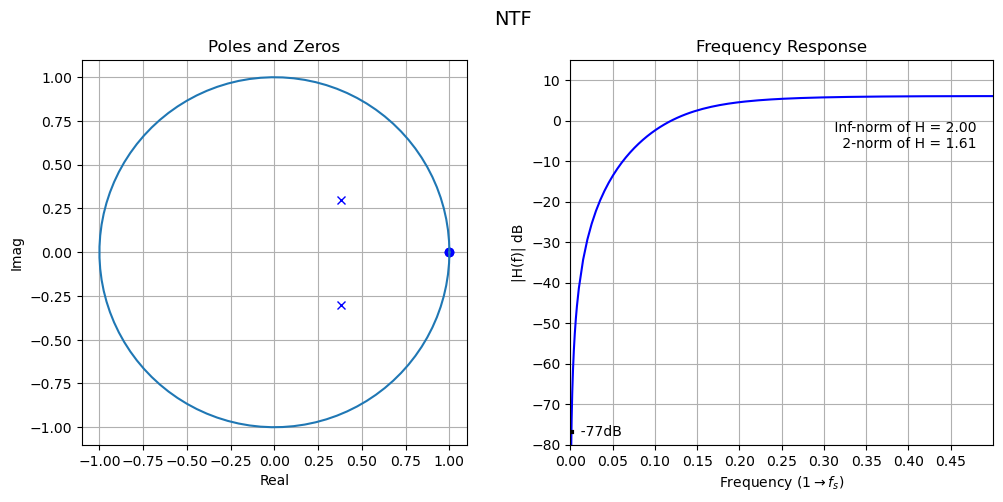

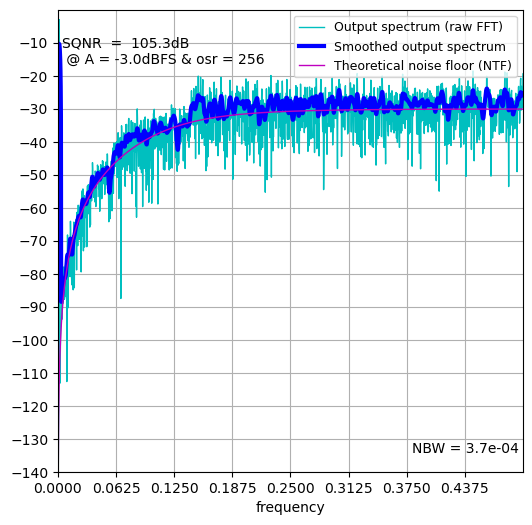

In [110]:
print("Generating NTF pole-zero plot...")
DocumentNTF(ntf0, osr, f0) # NTF pole-zero plot and low-pass NTF frequency response
figure(figsize=plotsize)
PlotExampleSpectrum(ntf0, M, osr, f0) # Time-domain simulation with input cosine signal. Try invoking simulateDSM by itself

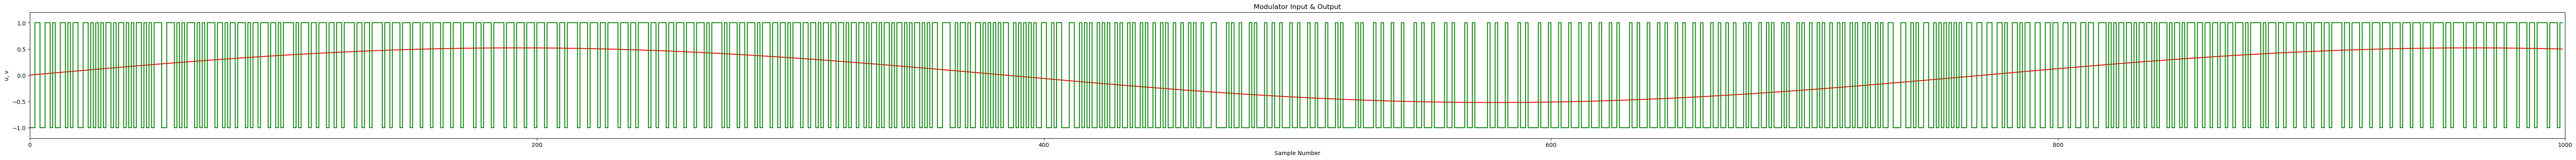

In [111]:
figure(figsize=(80, 4))
N = 65536
fB = int(np.ceil(N/(2.*osr)))
ftest = np.floor(2./3.*fB)
A = 0.52 # 0.52mVpp
u = 0.52*np.sin(2*np.pi*ftest/N*np.arange(N))
v, xn, xmax, y = simulateDSM(u, ntf0)
t = np.arange(1000)
step(t, u[t],'r')
step(t, v[t], 'g')
axis([0, 1000, -1.2, 1.2])
xlabel('Sample Number')
ylabel('u, v')
title('Modulator Input & Output');

Text(0, 0.5, 'u, v')

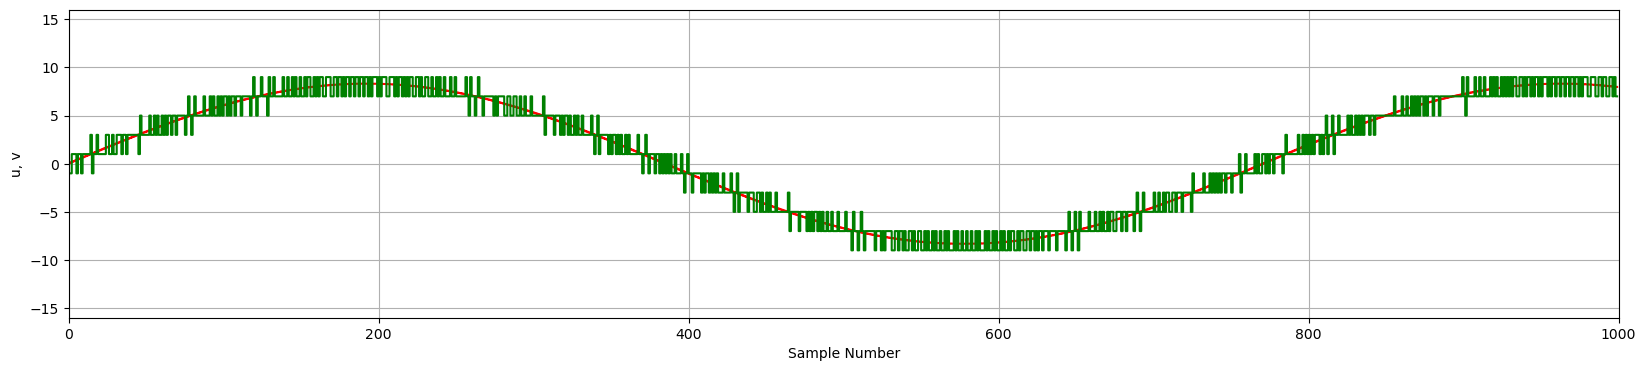

In [112]:
figure(figsize=(20, 4))
N = 65536
M = 16
fB = int(np.ceil(N/(2.*osr)))
ftest = np.floor(2./3*fB)
A = 0.52 # 0.52mVpp
u = 0.52*M*np.sin(2*np.pi*ftest/N*np.arange(N))
v, xn, xmax, y = simulateDSM(u, ntf0, 10)
t = np.arange(1000)
step(t, u[t],'r')
step(t, v[t], 'g')
grid(True)
axis([0, 1000, -M, M])
xlabel('Sample Number')
ylabel('u, v')

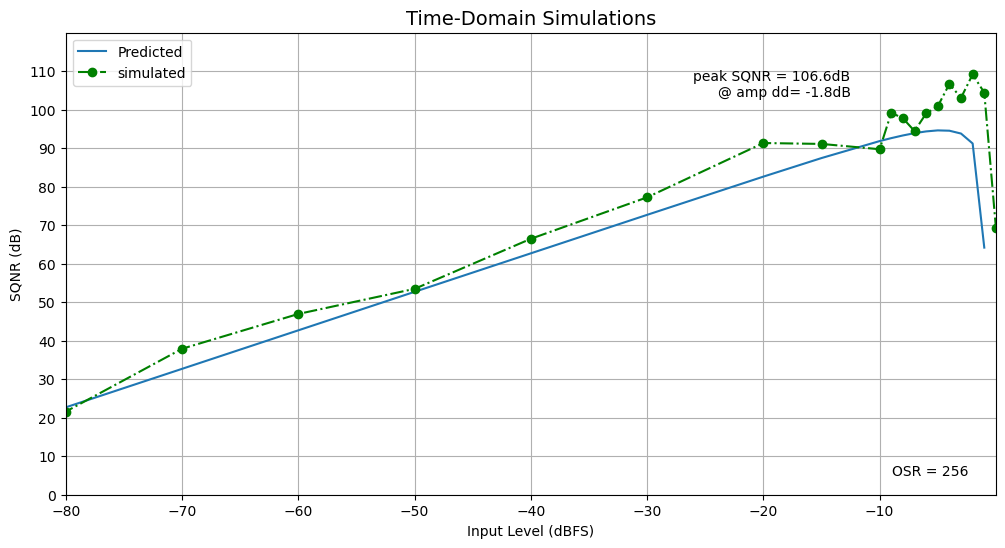

In [113]:
if nlev == 2:
    snr_pred, amp_pred, k0, k1, se = predictSNR(ntf0, osr)
snr, amp = simulateSNR(ntf0, osr, None, f0, nlev) # SNQR simulation

figure(figsize=plotsize)
if nlev == 2:
    plot(amp_pred, snr_pred, '-', label='Predicted')
plot(amp, snr,'o-.g', label='simulated')
xlabel('Input Level (dBFS)')
ylabel('SQNR (dB)')
peak_snr, peak_amp = peakSNR(snr, amp)
msg = 'peak SQNR = %4.1fdB  \n@ amp dd= %4.1fdB  ' % (peak_snr, peak_amp)
text(peak_amp-10, peak_snr, msg, horizontalalignment='right', verticalalignment='center');
msg = 'OSR = %d ' % osr
text(-2, 5, msg, horizontalalignment='right');
figureMagic([-80, 0], 10, None, [0, 120], 10, None, [12, 6], 'Time-Domain Simulations')
legend(loc=2);

In [114]:
print("Mapping to continuous time...")
tdac = [0., 1.] 
ABCDc, tdac2 = realizeNTF_ct(ntf0, form, tdac)

Ac, Bc, Cc, Dc = partitionABCD(ABCDc)
sys_c = []
for i in range(Bc.shape[1]):
    sys_c.append(ss2zpk(Ac, Bc, Cc, Dc, input=i))

print("done.")
print(f"ABCD matrix: {ABCDc}")
print(f"DAC timing (tdac2): {tdac2}")

Mapping to continuous time...
done.
ABCD matrix: [[ 0.          0.          0.47213596 -0.47213596]
 [ 1.          0.          0.         -0.99999999]
 [ 0.          1.          0.          0.        ]]
DAC timing (tdac2): [[-1. -1.]
 [ 0.  1.]]


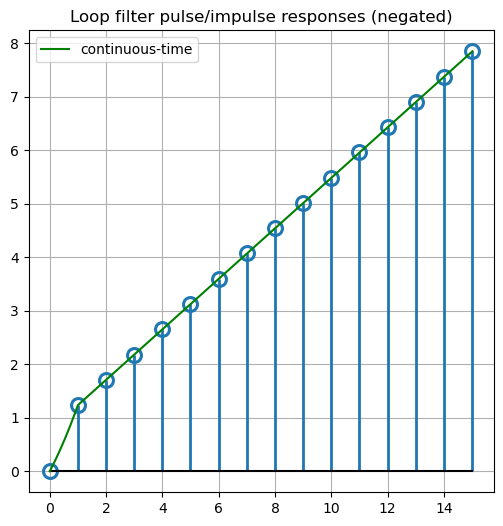

In [115]:
figure(figsize=plotsize)
n_imp = 15
y = -impL1(ntf0, n_imp)
lollipop(np.arange(n_imp + 1), y)
grid(True)
dt = 1./64
tppulse = np.vstack((np.zeros((1, 2)), tdac2[1:, :])).tolist()
yy = -pulse(sys_c, tppulse, dt, n_imp).squeeze()
t = np.linspace(0, n_imp + dt, int(n_imp/dt + 1))
plot(t, yy, 'g', label='continuous-time')
legend()
title('Loop filter pulse/impulse responses (negated)');

# Proper DT to CT mapping is observed if the green CT response matches the blue DT response

<Figure size 600x600 with 0 Axes>

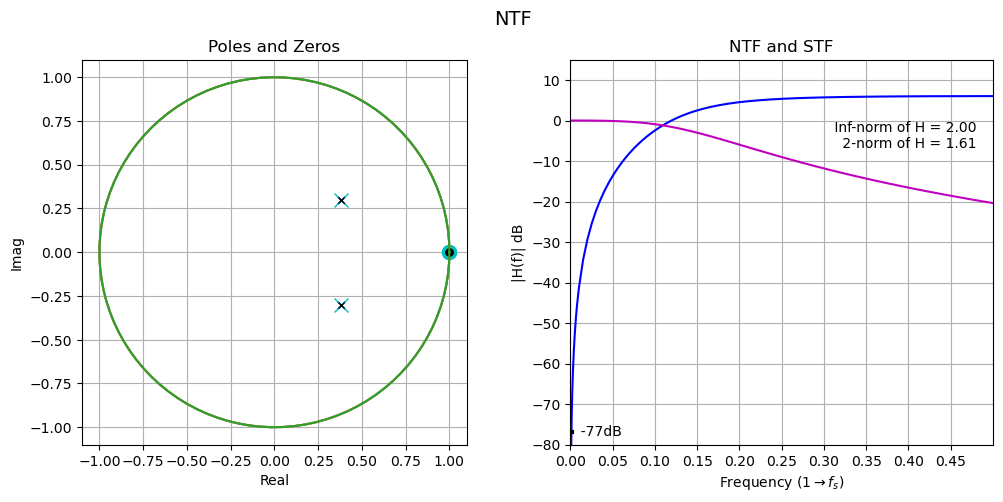

In [116]:
sys_d, Gp = mapCtoD(ABCDc, tdac2)
ABCD = np.vstack((
                  np.hstack((sys_d[0], sys_d[1])),
                  np.hstack((sys_d[2], sys_d[3]))
                ))
ntf, G = calculateTF(ABCD)
ntf = cancelPZ(ntf)
figure(figsize=plotsize)
DocumentNTF(ntf0, osr, f0)
subplot(121)
plotPZ(ntf, 'c', 10)
plotPZ(ntf0, 'k')


L0 = sys_c[0]
f = np.linspace(0, 0.5)
G = evalTFP(L0, ntf, f)
subplot(122)
plot(f, dbv(G), 'm')
title('NTF and STF');

In [117]:
print("Re-evaluating the SNR...")
snrR, ampR = simulateSNR(ABCD, osr, None, f0, nlev)
print("done.")

Re-evaluating the SNR...
done.


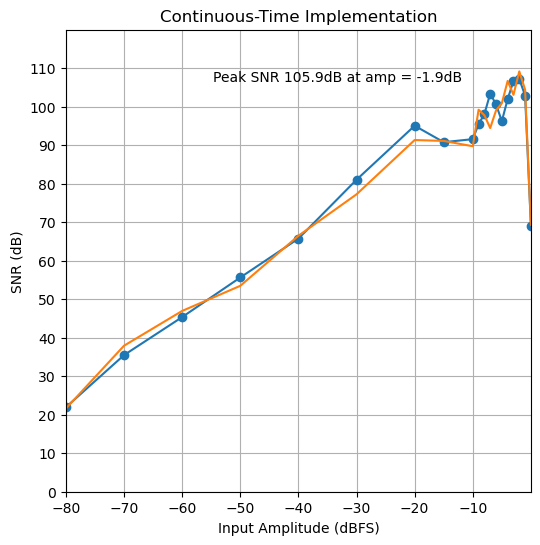

In [118]:
figure(figsize=plotsize)
plot(ampR, snrR, 'o-')
plot(amp, snr, '-')
peak_snrR, peak_ampR = peakSNR(snrR, ampR)
msg = 'Peak SNR %.1fdB at amp = %-.1fdB' % (peak_snrR, peak_ampR)
text(peak_ampR - 10, peak_snrR, msg, horizontalalignment='right', verticalalignment='bottom');
figureMagic([-80, 0], 10, 1, [0, 120], 10, 1, None,'SQNR vs. Input Amplitude')
xlabel('Input Amplitude (dBFS)')
ylabel('SNR (dB)')
title('Continuous-Time Implementation');

In [124]:
print("Doing dynamic range scaling...")
ABCDs, umax, S = scaleABCD(ABCD, nlev, f0, 1, None, None, 10000.0)
S = S[:order, :order]
Sinv = np.linalg.inv(S)
Acs = np.dot(np.dot(S, Ac), Sinv)
Bcs = np.dot(S, Bc)
Ccs = np.dot(Cc, Sinv)
ABCDcs = np.vstack((np.hstack((Acs, Bcs)),
                    np.hstack((Ccs, Dc))
                  ))
sys_cs = (Acs, Bcs, Ccs, Dc)
print("Done.")
print("During scaling, umax was found to be %g"% umax)
print("Scaled ABCD matrix:")
print(ABCDcs)

[a,g,b,c] = mapABCD(ABCD,form='CRFB')
print("Modulator topology coefficients:")
print(f"a = {a}, g = {g}, b = {b}, c = {c}")

Doing dynamic range scaling...
Done.
During scaling, umax was found to be 0.9
Scaled ABCD matrix:
[[ 0.          0.          0.31166731 -0.31166731]
 [ 0.32993848  0.          0.         -0.21779963]
 [ 0.          4.59137598  0.          0.        ]]
Modulator topology coefficients:
a = [0.47213596 0.76393201], g = [-0.], b = [ 0.47213596 -0.23606798  0.        ], c = [1. 1.]


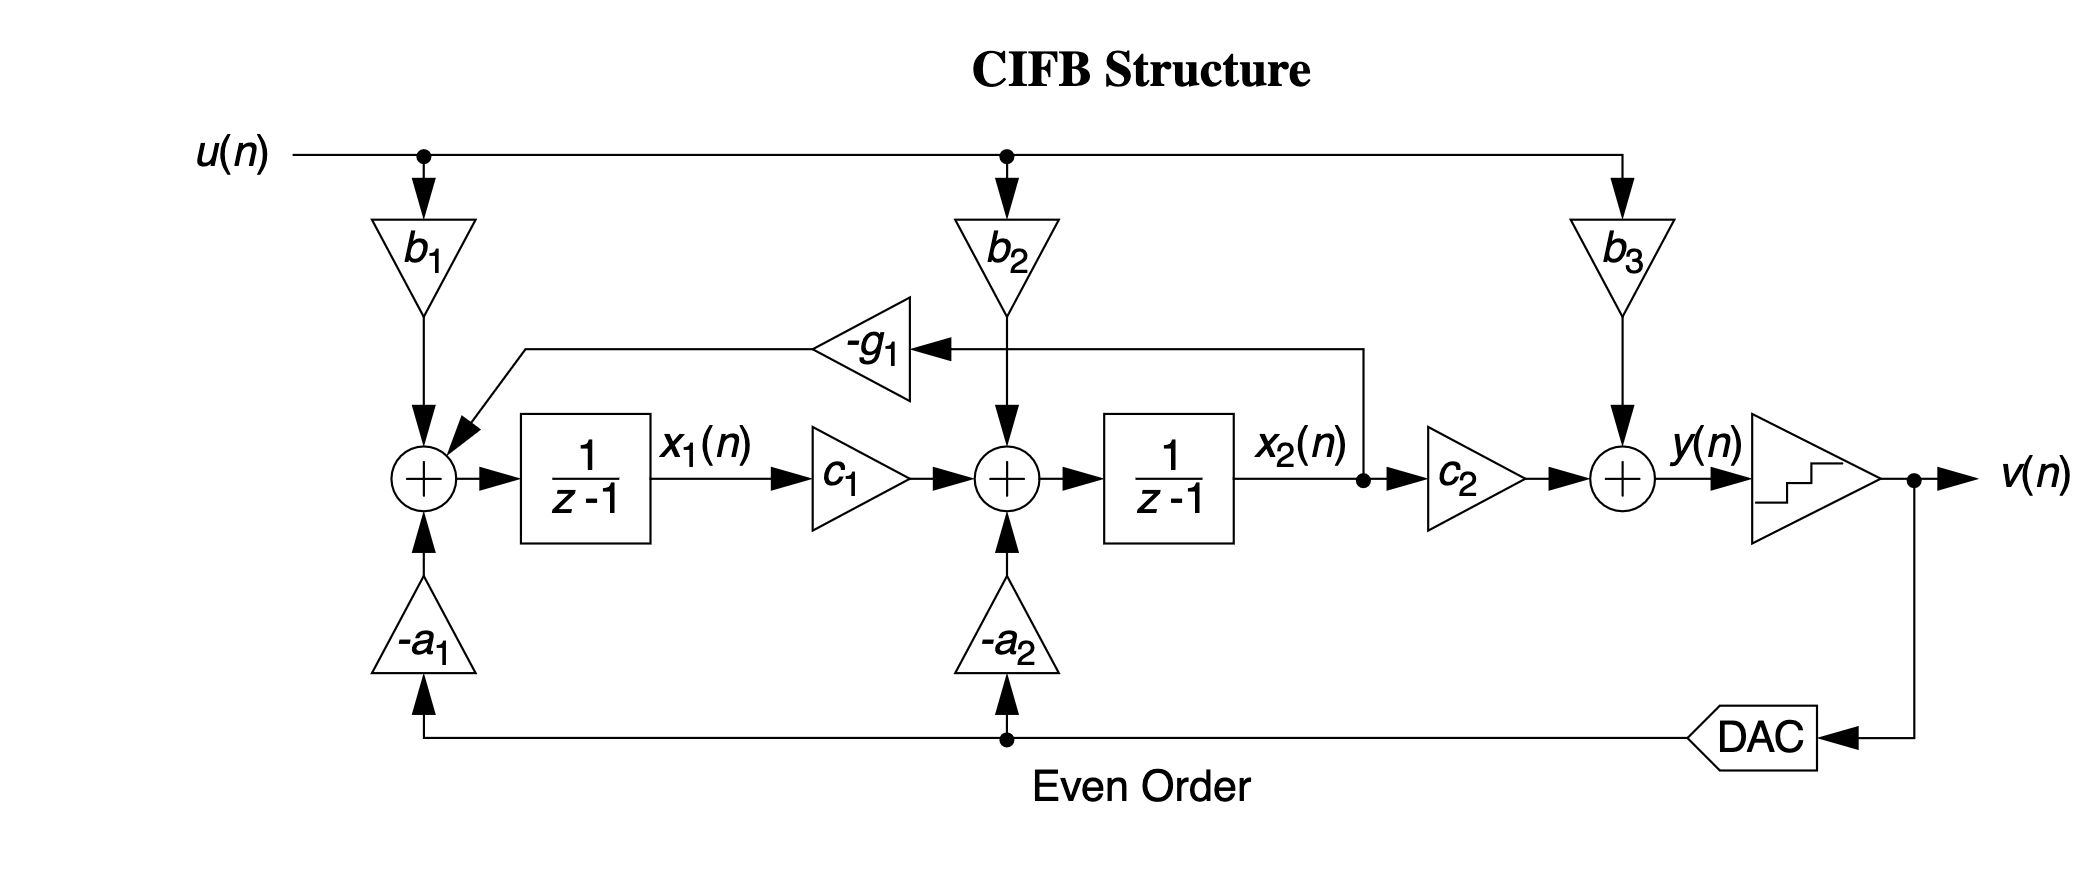

In [120]:
adc = {
    'order':order,
    'osr':osr,
    'M':M,
    'f0':f0,
    'ntf':ntf,
    'ABCD':ABCD,
    'umax':umax,
    'peak_snr':peak_snr,
    'form':form,
    'ABCDc':ABCDc,
    'tdac':tdac,
    'tdac2':tdac2,
    'L0':L0,
    'sys_c':sys_c,
    'ABCDcs':ABCDcs,
    'sys_cs':sys_cs
}
for k in sorted(adc.keys()):
    print(f"{k:}")
    if str(adc[k]).count('\n'):
        print("")
    print(adc[k])

ABCD

[[ 1.          0.          0.47213596 -0.47213596]
 [ 1.          1.          0.23606798 -1.23606797]
 [ 0.          1.          0.          0.        ]]
ABCDc

[[ 0.          0.          0.47213596 -0.47213596]
 [ 1.          0.          0.         -0.99999999]
 [ 0.          1.          0.          0.        ]]
ABCDcs

[[ 0.          0.          0.31166731 -0.31166731]
 [ 0.32993848  0.          0.         -0.21779963]
 [ 0.          4.59137598  0.          0.        ]]
L0
(array([], dtype=float64), array([0., 0.]), 0.4721359578690774)
M
16
f0
0.0
form
FB
ntf
(array([1., 1.]), array([0.38196601-0.30028312j, 0.38196601+0.30028312j]), 1.0)
order
2
osr
256
peak_snr
[[106.64944048]]
sys_c
[(array([], dtype=float64), array([0., 0.]), 0.4721359578690774), (array([-0.47213596]), array([0., 0.]), -0.999999993497982)]
sys_cs

(array([[0.        , 0.        ],
       [0.32993848, 0.        ]]), array([[ 0.31166731, -0.31166731],
       [ 0.        , -0.21779963]]), array([[0.        , 4.